**PatchTST**

# Code

## Configuration & General

In [30]:
!pip install torchmetrics -q

In [31]:
import os
import pandas as pd
import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError, R2Score
import joblib
from joblib import dump, load
from google.colab import drive
from sklearn import set_config
set_config(transform_output="pandas")


# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
wandb.login()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("ggplot")


BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
# MAIN_CSV_FILE = "fteng_main_latest.csv"
MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Drive already mounted at content/; to attempt to forcibly remount, call drive.mount("content/", force_remount=True).


In [32]:
countries_ids = {'United States': 0, 'India': 1, 'China': 2, 'Brazil': 3, 'Nigeria': 4, 'Germany': 5, 'Japan': 6, 'United Kingdom': 7, 'France': 8, 'Australia': 9, 'Kenya': 10, 'Mexico': 11, 'Indonesia': 12, 'Pakistan': 13, 'Bangladesh': 14, 'Egypt': 15, 'South Africa': 16, 'Canada': 17, 'Spain': 18, 'Italy': 19, 'Thailand': 20, 'Philippines': 21, 'Vietnam': 22, 'Argentina': 23, 'Colombia': 24}
targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

#### Feature Engineering Phase

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline


class FeatureEngineerMixin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        # Add Cyclic Encoding Transformations for dates and seasons.
        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        # A. Temporal Lags (The "Incubation Period")
        # We look back 1 week for pollution and temprature because diseases aren't instant.
        X_copy['pm25_ugm3_lag_1w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(1)
        X_copy['pm25_ugm3_lag_2w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(2)
        X_copy['pm25_ugm3_lag_4w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(4)

        X_copy['temp_lag_1w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(1)
        X_copy['temp_lag_2w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(2)

        # B. Rolling Averages (The "Chronic Exposure")
        # B1. We calculate the average temperature of the last 4 weeks.
        X_copy['temp_2w_avg'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
        )

        # B2. Rolling standard deviation (volatility)
        X_copy['temp_2w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).std())
        )

        X_copy['temp_4w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )

        # C. Mathematical Transformations (Non-Linearity)
        # Temperature usually has a U-shaped effect on health (bad if too hot OR too cold)
        X_copy['temp_squared'] = X_copy['temperature_celsius'] ** 2

        # Log-Transform Target Variables
        # We do NOT scale this later.
        # X_copy['food_security_index_log'] = np.log1p(X_copy['food_security_index'])


        # D. Scientific Logic: The human body adapts to gradual change.
        # Sudden spikes (Thermal Shock) cause heart attacks and asthma attacks.
        # D1. We calculate: (Current Week Value) - (Last Week Value)
        X_copy['temp_change_rate'] = X_copy.groupby('country_code')['temperature_celsius'].diff()
        X_copy['pm25_change_rate'] = X_copy.groupby('country_code')['pm25_ugm3'].diff()
        X_copy['precip_change_rate'] = X_copy.groupby('country_code')['precipitation_mm'].diff()

        # E. Calculate Spatial Lag for Respiratory Disease
        # We take the average disease rate of the 5 neighbors (excluding the country itself)
        coords = X_copy[['latitude' , 'longitude']].values

        nbrs = NearestNeighbors(n_neighbors=5 , algorithm='ball_tree').fit(coords)
        distances , indices = nbrs.kneighbors(coords)

        neighbor_idx = indices[: , 1:] # Drop the first one (itself)

        X_copy['spatial_lag_pm25'] = X_copy['pm25_ugm3'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp'] = X_copy['temperature_celsius'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp_anomaly'] = X_copy['temp_anomaly_celsius'].values[neighbor_idx].mean(axis=1)

        # F. The "Photochemical Smog" Effect
        # Scientific Logic: High heat catalyzes chemical reactions in pollutants (like Ozone/PM2.5), making them more toxic to the lungs.
        X_copy['pm25_temp_interaction'] = X_copy['pm25_ugm3'] * X_copy['temperature_celsius']
        X_copy['temp_precip_interaction'] = X_copy['temperature_celsius'] * X_copy['precipitation_mm']
        X_copy['pm25_precip_interaction'] = X_copy['pm25_ugm3'] * X_copy['precipitation_mm']

        # G. Hemisphere Indicators
        X_copy['is_northern'] = (X_copy['latitude'] > 0).astype(int)
        X_copy['is_tropical'] = (X_copy['latitude'].abs() < 23.5).astype(int)
        X_copy['distance_to_equator'] = X_copy['latitude'].abs()


        # I. The "Vulnerability" Effect
        # Scientific Logic: High pollution is manageable if Healthcare Access is high.
        # It becomes fatal if Healthcare is low.
        # We add a small epsilon (1e-6) to avoid division by zero.

        X_copy['pollution_vulnerability'] = X_copy['pm25_ugm3'] / (X_copy['healthcare_access_index'] + 1e-6)

        X_copy = X_copy.drop(columns=['month', 'week'])
        X_copy.fillna(X_copy.mean(numeric_only=True), inplace=True)

        self.feature_names_ = X_copy.columns.tolist()

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return self.feature_names_

# @title
class CountryIQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, country_col='country_id', multiplier=1.5):
        self.country_col = country_col
        self.multiplier = multiplier

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()
        self.bounds_ = {}

        for country in X[self.country_col].unique():
            mask = X[self.country_col] == country
            country_data = X.loc[mask, self.feature_names_]

            self.bounds_[country] = {}

            for col in self.feature_names_:
                if col == self.country_col: continue

                series = country_data[col].dropna()

                if len(series) < 10:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                Q1 = series.quantile(0.25)
                Q3 = series.quantile(0.75)
                IQR = Q3 - Q1

                if IQR == 0:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                lower = Q1 - self.multiplier * IQR
                upper = Q3 + self.multiplier * IQR
                self.bounds_[country][col] = (lower, upper)

        return self

    def transform(self, X):
        if not hasattr(self, 'bounds_'):
            raise ValueError("Capper has not been fitted yet. Call fit() first.")

        _X = X.copy()

        for country in _X[self.country_col].unique():
            mask = _X[self.country_col] == country

            if country not in self.bounds_:
                continue

            for col in self.feature_names_:
                if col == self.country_col: continue

                lower, upper = self.bounds_[country][col]
                _X.loc[mask, col] = _X.loc[mask, col].clip(lower=lower, upper=upper)

        return _X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return input_features

class SelectiveStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, drop_excluded=False):
        self.exclude_cols = exclude_cols or []
        self.drop_excluded = drop_excluded

    def fit(self, X, y=None):
        X = X.copy()

        self.scale_cols_ = [c for c in X.columns if c not in self.exclude_cols]

        self.scaler_ = RobustScaler()
        self.scaler_.fit(X[self.scale_cols_])

        self.feature_names_in_ = X.columns.tolist()
        self.feature_names_out_ = self.scale_cols_ if self.drop_excluded else self.feature_names_in_

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy[self.scale_cols_] = X_copy[self.scale_cols_].astype("float64")
        X_copy.loc[:, self.scale_cols_] = self.scaler_.transform(X_copy[self.scale_cols_])

        if self.drop_excluded:
            X_copy = X_copy[self.scale_cols_]

        return X_copy

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

countries_ids = joblib.load(os.path.join(MODELS_DIR, "country_to_idx.joblib"))
ids_countries = joblib.load(os.path.join(MODELS_DIR, "idx_to_country.joblib"))
pipeline = joblib.load(os.path.join(MODELS_DIR, "feature_pipeline_abdo.joblib"))

In [34]:
# @title
def ts_fold_split(df, k, min_train_years, val_years, test_years, year_col="year"):
    years = sorted(df[year_col].unique().tolist())

    min_years_needed = min_train_years + val_years + test_years
    assert len(years) >= min_years_needed, (
        f"Not enough unique years ({len(years)}) for "
        f"min_train_years={min_train_years}, "
        f"val_years={val_years}, "
        f"test_years={test_years}"
    )

    max_folds = len(years) - min_years_needed + 1
    k = min(k, max_folds)

    folds = []

    for i in range(k):
        train_end = min_train_years + i
        val_end = train_end + val_years
        test_end = val_end + test_years

        train_years = years[:train_end] # 0-3
        val_years_  = years[train_end:val_end] # 3-4
        test_years_ = years[val_end:test_end] # 4-5

        train_idx = df[df[year_col].isin(train_years)].index.tolist()
        val_idx   = df[df[year_col].isin(val_years_)].index.tolist()
        test_idx  = df[df[year_col].isin(test_years_)].index.tolist()

        if not train_idx or not val_idx or not test_idx:
            continue

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,

            "train_years": train_years,
            "val_years": val_years_,
            "test_years": test_years_,
        })

    return folds

In [35]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=['date'])
data_df['country_id'] = data_df['country_name'].map(countries_ids)
data_df.shape

(14100, 33)

## Checkpoint Saver

In [36]:
import pickle
import copy
import glob

class CheckpointSaver:
    def __init__(self, dirpath="./checkpoints", decreasing=True, save_model=True):
        self.dirpath = dirpath
        os.makedirs(dirpath, exist_ok=True)
        self.decreasing = decreasing
        self.save_model = save_model

        # Track the best metric
        self.best_metric = float('inf') if decreasing else float('-inf')

        # We store the best checkpoint in RAM (CPU).
        self.best_checkpoint_payload = None
        self.best_epoch = -1
        self.best_fold = -1
        self.run_id = None

    def update(self, model, fold, epoch, metric, run_id):
        """Checks if current model is best. If yes, caches it to RAM."""

        is_best = (metric < self.best_metric) if self.decreasing else (metric > self.best_metric)

        if not is_best:
            return False

        self.best_metric = metric
        self.best_epoch = epoch
        self.best_fold = fold
        self.run_id = run_id

        self.best_checkpoint_payload = {
            "epoch": epoch,
            "metric": metric,
            "model_state_dict": {k: v.cpu().clone() for k, v in model.state_dict().items()}
        }

        print(f"-> New Best Model found at Epoch {epoch} | Metric={metric:.4f}")
        return True

    @staticmethod
    def load_artifact_model(run_id, model_instance, project="sehetna/sehetna-main"):
        api = wandb.Api()
        artifact_path = f"{project}/{run_id}"

        try:
            artifact = api.artifact(artifact_path)
        except Exception as e:
            print(f"Error: Could not find artifact at {artifact_path}: {e}")
            return None

        print("-> Downloading artifact...")
        artifact_dir = artifact.download()

        pkl_files = glob.glob(os.path.join(artifact_dir, "*.pkl"))
        if not pkl_files:
            print("Error: No .pkl file found in the artifact.")
            return None

        model_pkl = pkl_files[0]
        print(f"-> Found checkpoint: {os.path.basename(model_pkl)}")

        with open(model_pkl, "rb") as f:
            checkpoint = pickle.load(f)

        state_dict = checkpoint.get("model_state_dict", checkpoint)

        # CRITICAL FIX: Remove _orig_mod. prefix if present
        cleaned_state_dict = {}
        has_orig_mod = False

        for key, value in state_dict.items():
            if key.startswith('_orig_mod.'):
                new_key = key.replace('_orig_mod.', '')
                cleaned_state_dict[new_key] = value
                has_orig_mod = True
            else:
                cleaned_state_dict[key] = value

        if has_orig_mod:
            print("-> Detected torch.compile() prefix (_orig_mod.), stripping it...")

        try:
            model_instance.load_state_dict(cleaned_state_dict)
            print("-> Weights successfully loaded into model.")
        except RuntimeError as e:
            print(f"-> Shape Mismatch! Are you loading Transformer weights into an MLP?")
            print(f"Error: {e}")

            # Debug info
            print("\nExpected keys (first 5):")
            for i, key in enumerate(list(model_instance.state_dict().keys())[:5]):
                print(f"  {key}")

            print("\nCheckpoint keys (first 5):")
            for i, key in enumerate(list(cleaned_state_dict.keys())[:5]):
                print(f"  {key}")

            return None

        return model_instance

    def __call__(self):
        """Call this ONCE at the very end of training."""
        if not self.save_model or self.best_checkpoint_payload is None:
            print("No model to save (or save_model=False).")
            return

        name = f"{self.run_id}-fold-{self.best_fold}-best-epoch-{self.best_epoch}.pkl"
        best_pkl = os.path.join(self.dirpath, name)

        description = f"Best Model: Fold {self.best_fold} | Epoch {self.best_epoch} | Metric={self.best_metric:.4f}"
        print(f"-> Saving to Disk: {name} ...")

        # Save to Disk
        with open(best_pkl, "wb") as f:
            pickle.dump(self.best_checkpoint_payload, f)

        # Upload to WandB
        if wandb.run is not None:
            print(f"-> Uploading to WandB...")
            artifact = wandb.Artifact(name=f"model-{self.run_id}", type="model", description=description)
            artifact.add_file(best_pkl)
            wandb.log_artifact(artifact)
            print("-> Upload Complete.")

## Feature Selection

In [37]:
# @title
climate_features = [
    # 'air_quality_index',
    # # 'aqi_pm', 'cardio_mortality_rate', 'cardio_mortality_rate_residual_lag2', 'cardio_mortality_rate_seasonal_lag2', 'cardio_mortality_rate_trend_lag2', 'country_code', 'country_id', 'country_name', 'date', 'day_of_week',
    # 'distance_to_equator',
    # # 'drought_indicator', 'extreme_weather_events', 'flood_indicator',
    # 'food_security_index',
    # # 'food_security_index_log',
    # 'gdp_per_capita_usd',
    # 'healthcare_access_index',
    # # 'heat_related_admissions', 'heat_related_admissions_residual_lag2', 'heat_related_admissions_seasonal_lag2', 'heat_related_admissions_trend_lag2',
    # # 'heat_wave_days',
    # # 'income_level',
    # # 'is_northern', 'is_tropical',
    # # 'latitude',
    # 'temp_squared',
    # # 'longitude',
    # 'mental_health_index',
    # 'month_cos',
    # 'month_sin',
    # 'pm25_change_rate',
    # 'pm25_precip_interaction',
    # 'pm25_temp_interaction',
    # 'pm25_ugm3',
    # 'pm25_ugm3_lag_1w',
    # 'pm25_ugm3_lag_2w',
    # 'pm25_ugm3_lag_4w',
    # 'pollution_vulnerability',
    # 'population_millions',
    # 'precip_change_rate',
    # 'precipitation_mm',
    # 'quarter',
    # # 'record_id', 'region', 'respiratory_disease_rate', 'respiratory_disease_rate_residual_lag2', 'respiratory_disease_rate_seasonal_lag2', 'respiratory_disease_rate_trend_lag2',
    # 'spatial_lag_pm25', 'spatial_lag_temp', 'spatial_lag_temp_anomaly',
    # 'temp_2w_avg',
    # 'temp_2w_volatility',
    # 'temp_4w_volatility',
    # 'temp_anomaly_celsius',
    # 'temp_change_rate',
    # 'temp_lag_1w',
    # 'temp_lag_2w',
    # 'temp_precip_interaction',
    # 'temperature_celsius',
    # 'uhs_service_coverage_index',
    # # 'vector_disease_risk_score', 'vector_disease_risk_score_residual_lag2', 'vector_disease_risk_score_seasonal_lag2', 'vector_disease_risk_score_trend_lag2', 'waterborne_disease_incidents', 'waterborne_disease_incidents_residual_lag2', 'waterborne_disease_incidents_seasonal_lag2', 'waterborne_disease_incidents_trend_lag2',
    # 'week_cos',
    # 'week_sin',
    # # 'year'

    # ==================================================

    'temperature_celsius',
    'temp_lag_1w',
    'temp_lag_2w',
    'temp_2w_avg',
    'temp_change_rate',
    'pm25_change_rate',
    'spatial_lag_temp',
    'temp_anomaly_celsius',
    'precipitation_mm',
    'air_quality_index',
    'aqi_pm',
    'pm25_ugm3',
    'pm25_ugm3_lag_1w',
    'pm25_ugm3_lag_2w',
    'spatial_lag_pm25',
    'pollution_vulnerability',
    'temp_precip_interaction',
    'pm25_temp_interaction',
    'pm25_precip_interaction',
    'gdp_per_capita_usd',
    'healthcare_access_index',
    'week_cos',
    'week_sin',
]

features = climate_features + targets
target_indices = [features.index(t) for t in targets]


## Data Preparation Helpers

### K-Fold Helpers

For *`spatiotemporal_kfold`* They won't ask:

> Can your model **predict next week in 2019**?

For *`temporal_leave_years_out`* They'll ask:

> Can this model still **work after climate patterns** or policies change?

Leaving out **1-3 year(s)** is the solution.

In [38]:
# @title

def apply_pipeline(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    # ---- Split X / y ----
    X_train = train_df
    y_train = train_df[targets]

    X_val = val_df
    y_val = val_df[targets]

    X_test = test_df
    y_test = test_df[targets]

    # ---- Fit pipeline on TRAIN FEATURES ONLY ----
    X_train_processed = pipeline.fit_transform(X_train)
    feature_names = pipeline.get_feature_names_out()

    X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=train_df.index)

    # ---- Scale y ----
    y_scaler = RobustScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)

    y_train_scaled_df = pd.DataFrame(y_train_scaled, columns=targets, index=train_df.index)

    joblib.dump(y_scaler, os.path.join(MODELS_DIR, "y_scaler.joblib"))

    train_proc = X_train_processed_df

    # ---- VAL ----
    X_val_processed_df = pd.DataFrame(pipeline.transform(X_val), columns=feature_names, index=val_df.index)

    y_val_scaled_df = pd.DataFrame(y_scaler.transform(y_val), columns=targets, index=val_df.index)

    val_proc = X_val_processed_df

    # ---- TEST ----
    X_test_processed_df = pd.DataFrame(pipeline.transform(X_test), columns=feature_names, index=test_df.index)

    y_test_scaled_df = pd.DataFrame(y_scaler.transform(y_test), columns=targets, index=test_df.index)

    test_proc = X_test_processed_df

    return train_proc, val_proc, test_proc

In [39]:
# @title
# def temporal_leave_years_out(dataset, val_years=2, test_years=3):
#     years = list(range(2015, 2026))

#     assert len(years) >= val_years + test_years + 1, f"Not enough unique years: {len(years)}"

#     train_end_year = years[-(val_years + test_years + 1)]
#     val_year_set = set(years[-(val_years + test_years):-test_years])
#     test_year_set = set(years[-test_years:])

#     train_idx, val_idx, test_idx = [], [], []

#     for idx, s in enumerate(dataset.samples):
#         y = s["year"]

#         if y <= train_end_year:
#             train_idx.append(idx)
#         elif y in val_year_set:
#             val_idx.append(idx)
#         elif y in test_year_set:
#             test_idx.append(idx)

#     return {
#         "train_idx": train_idx,
#         "val_idx": val_idx,
#         "test_idx": test_idx,
#         "train_years": f"{years[0]}-{train_end_year}",
#         "val_years": sorted(val_year_set),
#         "test_years": sorted(test_year_set),
#     }

### Build K-Fold Dataloaders

In [40]:
# @title
def build_dataloaders(df, seq_len=53, batch_size=128, k=5, min_train_years=5, val_years=1, test_years=1, is_cv=True):
    folds = []

    # 1. TimeSeries K-Fold split based on year column.
    folds_info = ts_fold_split(df, k, min_train_years, val_years, test_years)

    for i, fold in enumerate(folds_info, start=1):
        train_df = df.loc[fold["train_idx"]]
        val_df   = df.loc[fold["val_idx"]]
        test_df  = df.loc[fold["test_idx"]]

        # 2. Apply pipeline.
        train_proc, val_proc, test_proc = apply_pipeline(train_df, val_df, test_df)
        folds.append({
            # Loaders
            "train_loader": DataLoader(ClimateHealthDataset(train_proc, seq_len), batch_size=batch_size),
            "val_loader":   DataLoader(ClimateHealthDataset(val_proc, seq_len), batch_size=batch_size),
            "test_loader":  DataLoader(ClimateHealthDataset(test_proc, seq_len), batch_size=batch_size),

            # Metadata
            "train_years": fold["train_years"],
            "val_years":   fold["val_years"],
            "test_years":  fold["test_years"],
        })

    return folds

In [41]:
# @title
# def build_kfold_dataloaders(df, seq_len, batch_size=32, val_years=2, test_years=3):
#     full_dataset = ClimateHealthDataset(df, seq_len)

#     folds = [temporal_leave_years_out(full_dataset, val_years, test_years)]
#     results = []

#     for f in folds:
#         train_ds = Subset(full_dataset, f["train_idx"])
#         val_ds   = Subset(full_dataset, f["val_idx"])
#         test_ds  = Subset(full_dataset, f["test_idx"])

#         results.append({
#             "train_loader": DataLoader(train_ds, batch_size=batch_size, shuffle=True),
#             "val_loader": DataLoader(val_ds, batch_size=batch_size),
#             "test_loader": DataLoader(test_ds, batch_size=batch_size),

#             "train_years": f["train_years"],
#             "val_years": f["val_years"],
#             "test_years": f["test_years"]
#         })

#     return results

## Datasets & Model

In [42]:
class ClimateHealthDataset(Dataset):
    def __init__(self, df, seq_len):
        self.seq_len = seq_len
        self.samples = []
        df['country_id'] = df['country_name'].map(countries_ids)

        for c_id, country_df in df.groupby("country_id"):
            X = country_df[features].values.astype("float32")
            y = country_df[targets].values.astype("float32")
            years = country_df["year"].values

            for t in range(seq_len, len(country_df)):
                self.samples.append({"X": X[t - seq_len : t], "y": y[t], "c_id": c_id, "year": years[t]})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        X_num = torch.from_numpy(sample["X"]).float()
        country_id = torch.tensor(sample["c_id"], dtype=torch.long)
        y = torch.from_numpy(sample["y"]).float()

        return X_num, country_id, y

### Model

In [43]:
# @title
# fold = build_dataloaders(data_df, seq_len=24, batch_size=128, k=1, min_train_years=8, val_years=1, test_years=1)[0]
# data_iter = iter(fold['train_loader'])
# X, _, y = next(data_iter)
# model_config = PatchTSTConfig(
#     num_input_channels=len(features),
#     context_length=24,
#     prediction_length=1,

#     d_model=128,
#     n_heads=4,
#     num_hidden_layers=3,

#     patch_length=6,
#     stride=2,
#     dropout=0.3,

#     loss="mse"
# )
# model = PatchTSTForPrediction(model_config)

# outputs = model(past_values=X)

# # prediction_outputs: [B, 1, C]
# preds = outputs.prediction_outputs.squeeze(1)
# # # select only target columns
# preds = preds[:, target_indices]
# preds.shape

In [44]:
from transformers import PatchTSTConfig, PatchTSTForPrediction
class PatchTST(nn.Module):
    def __init__(self, config, num_features, target_indices):
        """
        target_indices: list of column indices corresponding to targets
                        inside the input feature dimension
        """
        super().__init__()

        self.target_indices = target_indices

        self.model_config = PatchTSTConfig(
            num_input_channels=num_features,
            context_length=config.seq_len,
            prediction_length=config.prediction_len,

            d_model=config.d_model,
            n_heads=config.n_heads,
            num_hidden_layers=config.num_layers,

            patch_length=config.patch_len,
            stride=config.patch_stride,
            dropout=config.dropout,

            loss="mse"
        )

        self.model = PatchTSTForPrediction(self.model_config)

    def forward(self, x):
        """
        x: [B, T, C]
        returns: [B, num_targets]
        """
        outputs = self.model(past_values=x)

        # prediction_outputs: [B, 1, C]
        preds = outputs.prediction_outputs.squeeze(1)

        # select only target columns
        preds = preds[:, self.target_indices]

        return preds


## Training & Validation Loops

In [45]:
from torch.amp import autocast, GradScaler

def train_one_epoch(model, dataloader, optimizer, criterion, scheduler = None):
    model.train()
    epoch_losses = []

    scaler = GradScaler()

    for X, _, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device.type):
            preds = model(X)
            loss = criterion(preds, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))


In [46]:
@torch.no_grad()
def validate_one_epoch(model, dataloader, criterion):
    model.eval()

    mse_metric = MeanSquaredError().to(device)
    mae_metric = MeanAbsoluteError().to(device)
    r2_metric = R2Score().to(device)

    total_loss, total_samples = 0.0, 0

    for X, _, y in dataloader:
        X, y = X.to(device), y.to(device)

        with autocast(device.type):
            preds = model(X)
            loss = criterion(preds, y)

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        mse_metric.update(preds, y)
        mae_metric.update(preds, y)
        r2_metric.update(preds, y)

    mse = mse_metric.compute().item()
    mae = mae_metric.compute().item()
    rmse = mse ** 0.5
    r2 = r2_metric.compute().item()
    avg_loss = total_loss / total_samples
    return avg_loss, mae, rmse, r2

In [47]:
def train(model, fold, train_loader, val_loader, optimizer, criterion, run_id, config, scheduler = None):
    Saver = CheckpointSaver()
    for epoch in range(1, config.e + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
        v_loss, mae, rmse, r2 = validate_one_epoch(model, val_loader, criterion)
        current_lr = optimizer.param_groups[0]['lr']

        wandb.log({"train/loss": t_loss, "val/loss_mse": v_loss, "val/rmse": rmse, "val/mae": mae, "val/r2": r2, "lr": current_lr, "epoch": epoch, "fold": fold})
        print(f"Fold {fold} | Epoch {epoch} => Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val RMSE: {rmse:.4f} | Val MAE: {mae:.4f} | Val R2: {r2:.4f}")

        Saver.update(model, fold, epoch, mae, run_id)

    Saver()

## Start Training

In [48]:
from torch.optim.lr_scheduler import OneCycleLR

def start(config=None):
    with wandb.init(config=config) as run:
        from sklearn import set_config
        set_config(transform_output="pandas")

        config = wandb.config
        folds = build_dataloaders(data_df, config.seq_len, config.batch_size, config.k, config.min_train_years, config.val_years, config.test_years)

        for i, fold in enumerate(folds, start=1):
            model = PatchTST(config=config, num_features=len(features), target_indices=target_indices).to(device)
            criterion = nn.MSELoss()

            optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
            scheduler = None

            if config.scheduler:
                scheduler = OneCycleLR(optimizer, max_lr=config.lr * 10, steps_per_epoch=len(fold["train_loader"]), epochs=config.e)

            print(f"\n--- Fold {i} | Train: {fold['train_years']} | Val: {fold['val_years']} ---")
            train(model, i, fold["train_loader"], fold["val_loader"], optimizer, criterion, run.id, config, scheduler)

## Sweep Configuration

In [50]:
# ------- Versioning -------
# v0 Major: changing and introducing new layers, defining new splitting technique, or adjusting features.
# v0.0 minor: adding/removing new sweep configuration parameter keys.
# v0.0.0 patch: updating values of sweep configuration parameters.

sweep_configuration = {
    "name": "climate-health-patchtst-v6.1.2",
    "method": "bayes",
    "metric": { "name": "val/mae", "goal": "minimize" },
    "parameters": {
        # MODEL ARCHITECTURE
        "d_model": { "values": [128] },
        "n_heads": { "values": [4] },
        "num_layers": { "values": [3] },
        # PATCHES CONFIG
        "patch_len": { "values": [6] },
        "patch_stride": { "values": [2] },
        # OVERFIT HANDLING
        "dropout": { "distribution": "uniform", "min": 0.15, "max": 0.2 },
        # OPTIMIZATION
        "lr": { "distribution": "log_uniform_values", "min": 1e-3, "max": 3e-2 },
        "weight_decay": { "distribution": "log_uniform_values", "min": 1e-3, "max": 5e-2 },
        "scheduler": { "value": False },
        # DATA PREPARATION
        "seq_len": { "values": [8] },
        "prediction_len": { "values": [1] },
        "k": {"value": 1},
        "min_train_years": {"value": 8},
        "val_years": {"value": 1},
        "test_years": {"value": 1},

        "batch_size": { "value": 128 },
        "e": { "value": 32 }
    }
}

desc = f"""This sweep aims to optimize the PatchTST model for climate-health predictions.

The model incorporates:
*   **PatchTSTForPrediction**: A Transformer-based model from the HuggingFace `transformers` library for time series forecasting.
*   **Linear Projection**: A final dense layer to project the model's output to the desired number of target variables.

The primary objective is to **minimize Mean Absolute Error (MAE)** on the validation set.

Key parameters being tuned include:
```py
{sweep_configuration['parameters']}
```

## Change Log
### V3.0.0. TESTING PATCHTST CODE
* using temporal_leave_years_out (Leaving out **1-3 year(s)**): another approach was introduced to split the data instead of spatiotemporal_kfold

### V3.1.0. FIXED HYPERPARAMETERS CONFIG

### V4.0.0. FEATURES SELECTION ADJUSTMENT
```py
{climate_features}
```
"""

sweep_configuration["description"] = desc

## Initialize Sweep

In [51]:
wandb_project = "sehetna-main"
sweep_id = wandb.sweep(sweep=sweep_configuration, project=wandb_project)
wandb.agent(sweep_id, function=start, count=1)

Create sweep with ID: wauppx0h
Sweep URL: https://wandb.ai/sehetna/sehetna-main/sweeps/wauppx0h


wandb: Agent Starting Run: 5mwxeozq with config:
wandb: 	batch_size: 128
wandb: 	d_model: 128
wandb: 	dropout: 0.17238952130588506
wandb: 	e: 32
wandb: 	k: 1
wandb: 	lr: 0.0021088817429640496
wandb: 	min_train_years: 8
wandb: 	n_heads: 4
wandb: 	num_layers: 3
wandb: 	patch_len: 6
wandb: 	patch_stride: 2
wandb: 	prediction_len: 1
wandb: 	scheduler: False
wandb: 	seq_len: 8
wandb: 	test_years: 1
wandb: 	val_years: 1
wandb: 	weight_decay: 0.0022837015401815574



--- Fold 1 | Train: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022] | Val: [2023] ---
Fold 1 | Epoch 1 => Train Loss: 0.8934 | Val Loss: 0.7748 | Val RMSE: 0.8802 | Val MAE: 0.5812 | Val R2: 0.3060
-> New Best Model found at Epoch 1 | Metric=0.5812
Fold 1 | Epoch 2 => Train Loss: 0.9133 | Val Loss: 0.7962 | Val RMSE: 0.8923 | Val MAE: 0.5777 | Val R2: 0.3318
-> New Best Model found at Epoch 2 | Metric=0.5777
Fold 1 | Epoch 3 => Train Loss: 0.9033 | Val Loss: 0.8280 | Val RMSE: 0.9099 | Val MAE: 0.5837 | Val R2: 0.3303
Fold 1 | Epoch 4 => Train Loss: 0.8907 | Val Loss: 0.8875 | Val RMSE: 0.9421 | Val MAE: 0.6250 | Val R2: 0.1715
Fold 1 | Epoch 5 => Train Loss: 0.8886 | Val Loss: 0.8042 | Val RMSE: 0.8968 | Val MAE: 0.5985 | Val R2: 0.2562
Fold 1 | Epoch 6 => Train Loss: 0.9022 | Val Loss: 0.7744 | Val RMSE: 0.8800 | Val MAE: 0.5801 | Val R2: 0.3088
Fold 1 | Epoch 7 => Train Loss: 0.9039 | Val Loss: 0.8029 | Val RMSE: 0.8961 | Val MAE: 0.5798 | Val R2: 0.3257
Fold 1 | Epoch 8 => Train 

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▄█▆▃▃▆▆▂▃▅▂▆▁▄▇▁▅▅▄▃▅▄▅▅▆▂▃▄▃▂▂▂
val/loss_mse,▁▂▄█▃▁▃▁▁▂▁▂▂▁▁▅▂▃▂▁▃▁▃▂▂▃▂▂▁▂▂▂
val/mae,▂▁▂█▄▁▁▂▁▁▂▂▂▁▁▅▂▂▁▁▂▂▃▂▂▃▃▂▁▂▂▂
val/r2,▇██▁▅▇█▇▇▇▇▆▇▇▇▄▇▆██▆▇▆▆▇▆▆▇▇▇▆▇
val/rmse,▁▂▄█▃▁▃▁▁▂▁▂▂▁▁▅▂▃▂▁▃▁▃▂▃▃▂▂▁▂▂▂
epoch,32
fold,1
lr,0.00211


## Testing & Inference

### Testing on the test data loader

In [55]:
from types import SimpleNamespace

test_config = SimpleNamespace(
    batch_size=128,
    d_model=128,
    dropout=0.1883665437626323,
    e=32,
    k=1,
    lr=0.009707265376473876,
    min_train_years=8,
    n_heads=4,
    num_layers=3,
    patch_len=6,
    patch_stride=2,
    prediction_len=1,
    scheduler=False,
    seq_len=8,
    test_years=1,
    val_years=1,
    weight_decay=0.03831498090798732,
)

Saver = CheckpointSaver()
model_instance = PatchTST(test_config, len(features), target_indices).to(device)

best_model = Saver.load_artifact_model('model-nvefcg0z:v0', model_instance)
best_model

-> Downloading artifact...


wandb:   1 of 1 files downloaded.  


-> Found checkpoint: nvefcg0z-fold-1-best-epoch-24.pkl
-> Weights successfully loaded into model.


PatchTST(
  (model): PatchTSTForPrediction(
    (model): PatchTSTModel(
      (scaler): PatchTSTScaler(
        (scaler): PatchTSTStdScaler()
      )
      (patchifier): PatchTSTPatchify()
      (masking): Identity()
      (encoder): PatchTSTEncoder(
        (embedder): PatchTSTEmbedding(
          (input_embedding): Linear(in_features=6, out_features=128, bias=True)
        )
        (positional_encoder): PatchTSTPositionalEncoding(
          (positional_dropout): Identity()
        )
        (layers): ModuleList(
          (0-2): 3 x PatchTSTEncoderLayer(
            (self_attn): PatchTSTAttention(
              (k_proj): Linear(in_features=128, out_features=128, bias=True)
              (v_proj): Linear(in_features=128, out_features=128, bias=True)
              (q_proj): Linear(in_features=128, out_features=128, bias=True)
              (out_proj): Linear(in_features=128, out_features=128, bias=True)
            )
            (dropout_path1): Identity()
            (norm_sublayer1)

In [56]:
def test_model(model, dataloader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_num, _, y in dataloader:
            X_num, y = X_num.to(device), y.to(device)

            with autocast(device.type):
                preds = model(X_num)

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    return torch.cat(all_preds), torch.cat(all_targets)

folds = build_dataloaders(data_df, test_config.seq_len, test_config.batch_size, test_config.k, test_config.min_train_years, test_config.val_years, test_config.test_years)
all_preds, all_targets = test_model(best_model, folds[0]['test_loader'])

In [59]:
# print("Actual:      ", all_targets.numpy()[:5])
# print("Predictions: ", all_preds.numpy()[:5])

### Calculate metrics per target.

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save: results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(all_targets.numpy(), all_preds.numpy())

In [61]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

Overall Macro RMSE: 0.8054851198045467


,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions
RMSE,0.619022,0.792727,1.487522,0.635358,0.492797
MAE,0.495587,0.624917,0.910603,0.503672,0.308685
R2,0.255825,-0.163453,0.749924,0.233051,0.587973
NRMSE_%,15.197750,18.862324,7.883865,14.727984,18.171879


### Visualization & Conclusion

> *Model performance was evaluated using RMSE, MAE, and NRMSE for each health outcome independently to account for scale differences across indicators. RMSE was emphasized due to its sensitivity to extreme health events such as heat-related admissions.*



In [62]:
y_true, y_pred = all_targets.numpy(), all_preds.numpy()
residuals = y_true - y_pred

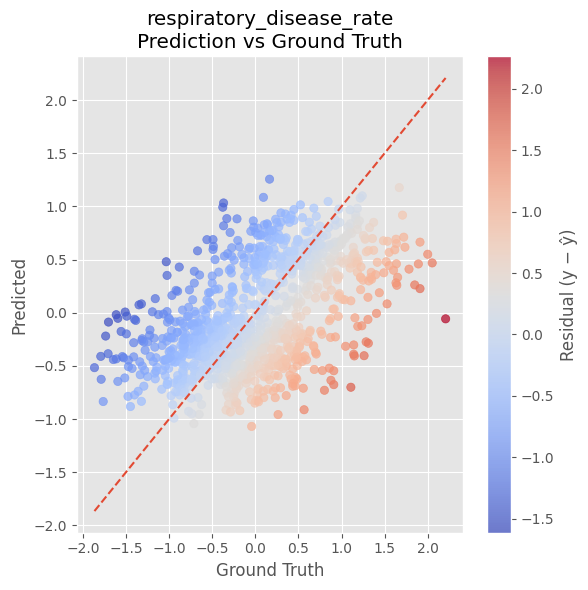

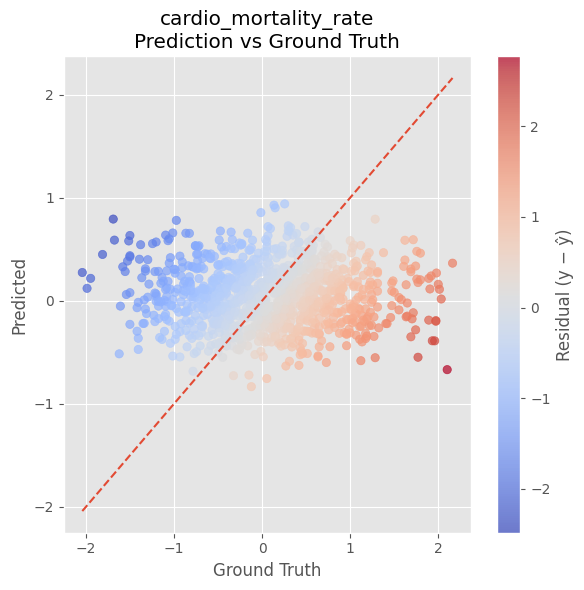

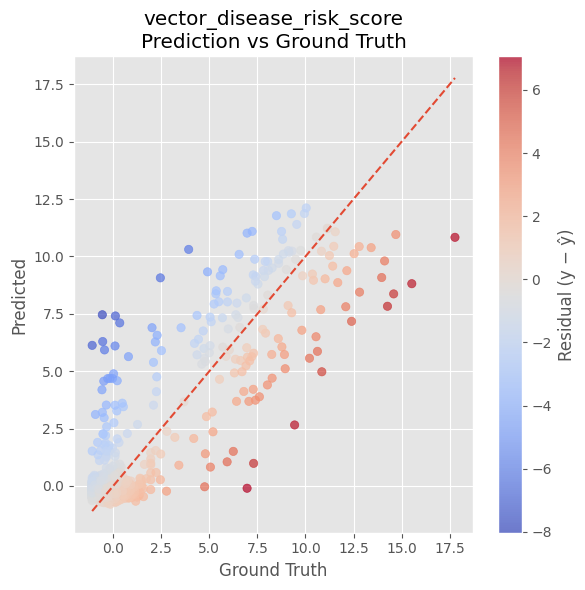

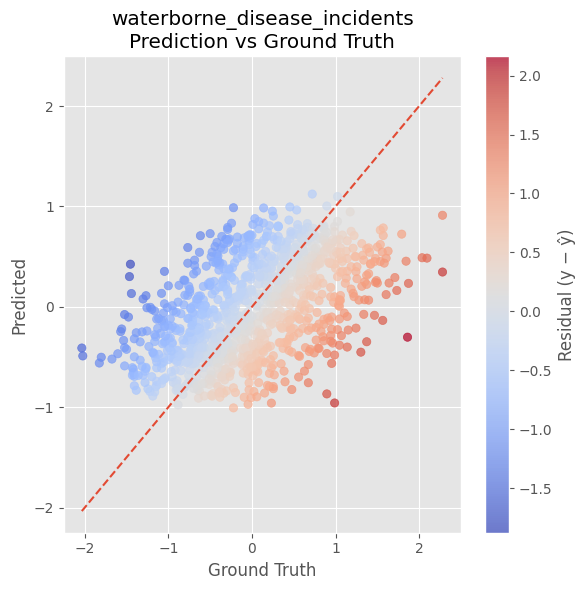

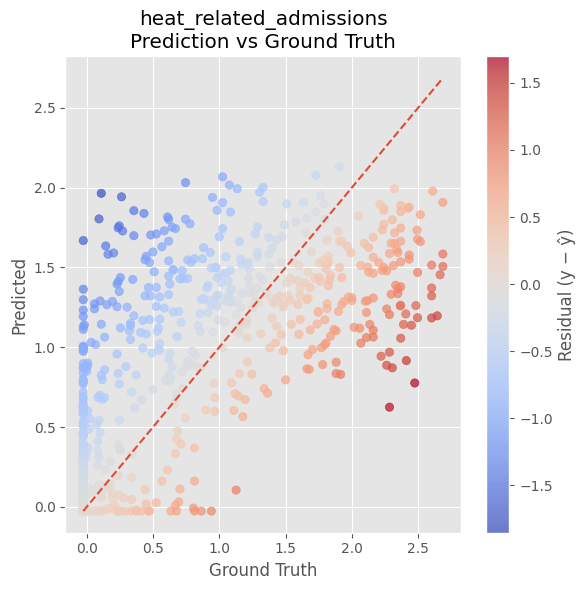

In [63]:
for i, target in enumerate(targets):
    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        y_true[:, i],
        y_pred[:, i],
        c=residuals[:, i],
        cmap="coolwarm",
        alpha=0.7
    )

    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"{target}\nPrediction vs Ground Truth")

    plt.colorbar(sc, label="Residual (y − ŷ)")
    plt.tight_layout()
    plt.show()


> *Prediction VS observation scatter plots were used to visually assess model calibration and error dispersion for each health indicator independently. The diagonal line represents perfect prediction.*

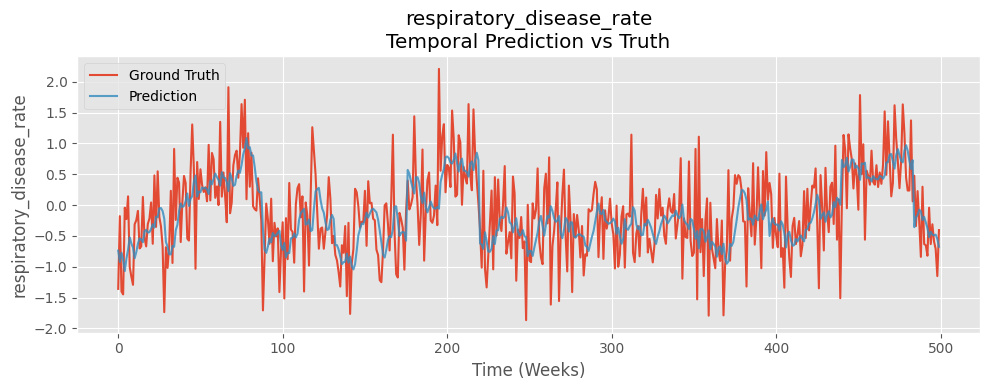

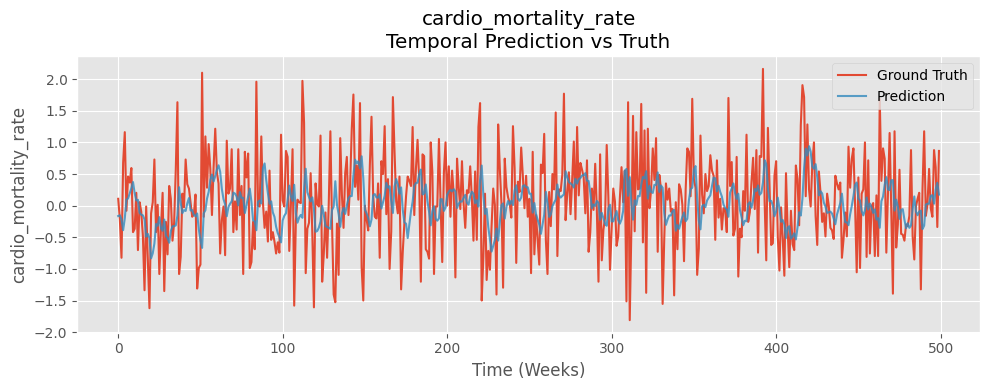

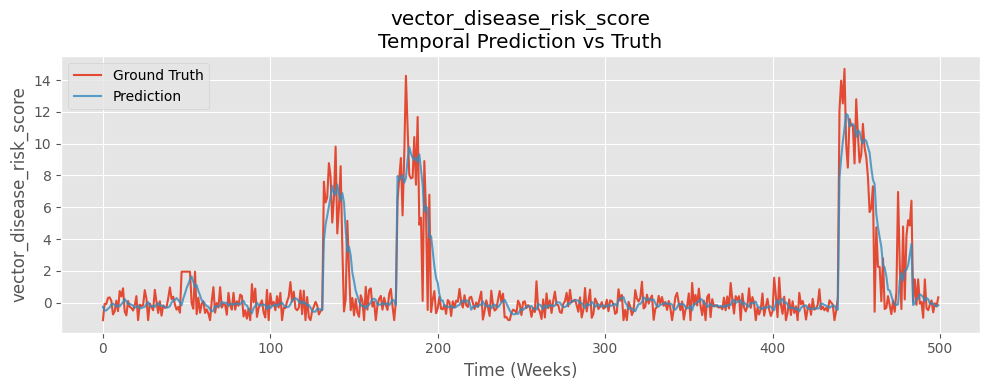

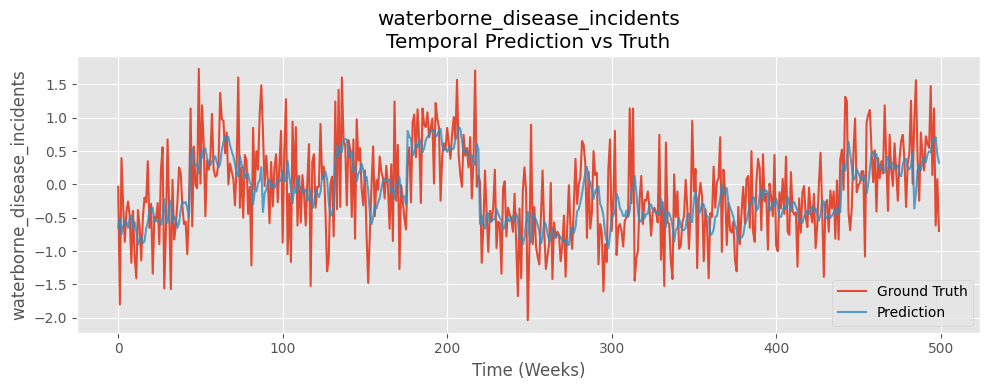

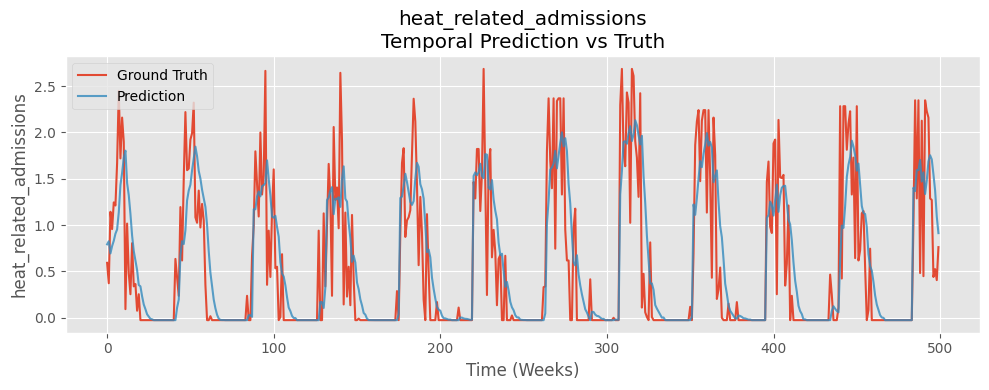

In [64]:
for i, target in enumerate(targets):

    plt.figure(figsize=(10, 4))

    plt.plot(y_true[:500, i], label="Ground Truth")
    plt.plot(y_pred[:500, i], label="Prediction", alpha=0.8)

    plt.xlabel("Time (Weeks)")
    plt.ylabel(target)
    plt.title(f"{target}\nTemporal Prediction vs Truth")
    plt.legend()

    plt.tight_layout()
    plt.show()



> *Residual-based visual diagnostics were used to assess model calibration, temporal consistency, and performance under extreme health events. Error dispersion increased during high-magnitude outcomes, highlighting the intrinsic difficulty of forecasting rare public-health spikes.*



### Inference